In [86]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import importlib
import pickle
import sys
import os
import re
import seaborn as sns
from os.path import join as pjoin

import catrace.exp_collection as ecl
import catrace.process_time_trace as ptt
import catrace.plot_trace as pltr
import catrace.pattern_correlation as catpcr

from catrace.dataset import load_dataset_config

ob_dsconfig= load_dataset_config('../dataset_configs/juvenile_dataset_OB_t7.json')
dp_dsconfig= load_dataset_config('../dataset_configs/juvenile_dataset_t7.json')

In [88]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5

In [89]:
# Compute similarities for each fish
importlib.reload(catpcr)
import catrace.similarity as catsim
importlib.reload(catsim)

window = [25, 110]
in_dir = dp_dsconfig.processed_trace_dir
exp_list = dp_dsconfig.exp_list
metric = 'cosine'
similarity_func = catsim.cosine_distance
# metric = 'pattern_correlation'
# similarity_func = catsim.pattern_correlation
out_dir = pjoin(in_dir, f'{metric}_timecourse')

def select_and_compute_pattern_correlation_timecourse(dff, odors, time_window, **kwargs):
    dff = ptt.select_odors_df(dff, odors)
    dff = ptt.sort_odors(dff, odors)
    dff = catsim.compute_similarity_mat_timecourse(dff, **kwargs)
    return dff

overwrite = False
if not os.path.exists(out_dir) or overwrite:
    os.makedirs(out_dir, exist_ok=True)
    func = select_and_compute_pattern_correlation_timecourse
    compute_pcr_explist = ecl.process_data_db_decorator(func, exp_list,
                                                        out_dir, in_dir)
    compute_pcr_explist(time_window=window, odors=dp_dsconfig.odors_stimuli, window_size=5, similarity_func=similarity_func)
sim_dir = out_dir
print(sim_dir)

F:\FMI_tachyon_hubo\Dp_manifold\juvenile_dataset\data\spike_prob_long\per_odor_aligned\index_formatted_firing_rate\cosine_timecourse


In [90]:
# Compute similarities for each fish
importlib.reload(catpcr)
import catrace.similarity as catsim
importlib.reload(catsim)

in_dir = ob_dsconfig.processed_trace_dir
exp_list = ob_dsconfig.exp_list
out_dir = pjoin(in_dir, f'{metric}_timecourse')

def select_and_compute_pattern_correlation_timecourse(dff, odors, time_window, **kwargs):
    dff = ptt.select_odors_df(dff, odors)
    dff = ptt.sort_odors(dff, odors)
    dff = catsim.compute_similarity_mat_timecourse(dff, **kwargs)
    return dff

overwrite = False
if not os.path.exists(out_dir) or overwrite:
    os.makedirs(out_dir, exist_ok=True)
    func = select_and_compute_pattern_correlation_timecourse
    compute_pcr_explist = ecl.process_data_db_decorator(func, exp_list,
                                                        out_dir, in_dir)
    compute_pcr_explist(time_window=window, odors=ob_dsconfig.odors_stimuli, window_size=5, similarity_func=similarity_func)
sim_dir = out_dir
print(sim_dir)

F:\FMI_tachyon_hubo\Dp_manifold\juvenile_dataset\data\OB\spike_prob_long\per_odor_aligned\PN\index_formatted\firing_rate\cosine_timecourse


In [91]:
import pandas as pd
from os.path import join as pjoin
sim_dir = f'{metric}_timecourse'

ob_sim_dir = pjoin(ob_dsconfig.processed_trace_dir, sim_dir)
dp_sim_dir = pjoin(dp_dsconfig.processed_trace_dir, sim_dir)

from catrace.run.run_pattern_similarity import read_mats_from_dir
ob_simdf_list, _ = read_mats_from_dir(ob_sim_dir, ob_dsconfig.exp_list)
ob_simdf = pd.concat(ob_simdf_list, keys=ob_dsconfig.exp_list, names=['fish_id', 'condition'])
dp_simdf_list, _ = read_mats_from_dir(dp_sim_dir, dp_dsconfig.exp_list)
dp_simdf = pd.concat(dp_simdf_list, keys=dp_dsconfig.exp_list, names=['fish_id', 'condition'])

ob_simdf

2021-07-15-DpOBEM-N2_OB None
2021-07-16-DpOBEM-N3_OB None
2021-12-10-DpOBEM-N4_OB None
2021-12-31-DpOBEM-N7_OB None
2022-02-13-DpOBEM-N10_OB None
2022-02-20-DpOBEM-N11_OB None
2021-02-05-DpOBEM-JH9_OB None
2021-03-18-DpOBEM-JH10_OB None
2021-03-19-DpOBEM-JH10_OB None
2021-04-02-DpOBEM-JH11_OB None
2021-04-03-DpOBEM-JH11_OB None
2021-05-01-DpOBEM-JH13_OB None
2021-05-22-DpOBEM-JH14_OB None
2021-09-15-DpOBEM-JH20_OB None
2021-09-17-DpOBEM-JH20_OB None
2021-09-18-DpOBEM-JH20_OB None
2021-07-30-DpOBEM-JH17_OB None
2021-07-31-DpOBEM-JH17_OB None
2021-09-02-DpOBEM-JH18_OB None
2021-09-03-DpOBEM-JH18_OB None
2021-09-04-DpOBEM-JH18_OB None
2021-09-29-DpOBEM-JH21_OB None
2021-10-01-DpOBEM-JH21_OB None
2021-10-02-DpOBEM-JH21_OB None
2021-10-14-DpOBEM-JH22_OB None
2021-11-10-DpOBEM-JH23_OB None
2021-11-11-DpOBEM-JH23_OB None
2021-11-14-DpOBEM-JH23_OB None
2021-11-24-DpOBEM-JH24_OB None
2021-11-27-DpOBEM-JH24_OB None
2021-11-26-DpOBEM-JH24_OB None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_

odor                                                                     Phe  \
trial                                                                      0   
fish_id                   condition start_time end_time odor trial             
2021-07-15-DpOBEM-N2_OB   naive     0          5        Phe  0      0.000000   
                                                             1      0.506950   
                                                             2      0.463921   
                                                        Arg  0      0.474491   
                                                             1      0.459489   
...                                                                      ...   
2021-11-26-DpOBEM-JH24_OB phe-trp   155        160      TCA  1      0.697858   
                                                             2      0.730062   
                                                        GCA  0      0.694495   
                                                             1      0.701807   
                                                             2      0.700449   

odor                                                                          \
trial                                                                      1   
fish_id                   condition start_time end_time odor trial             
2021-07-15-DpOBEM-N2_OB   naive     0          5        Phe  0      0.506950   
                                                             1      0.000000   
                                                             2      0.497540   
                                                        Arg  0      0.488502   
                                                             1      0.530942   
...                                                                      ...   
2021-11-26-DpOBEM-JH24_OB phe-trp   155        160      TCA  1      0.694904   
                                                             2      0.759952   
                                                        GCA  0      0.596186   
                                                             1      0.727330   
                                                             2      0.689933   

odor                                                                          \
trial                                                                      2   
fish_id                   condition start_time end_time odor trial             
2021-07-15-DpOBEM-N2_OB   naive     0          5        Phe  0      0.463921   
                                                             1      0.497540   
                                                             2      0.000000   
                                                        Arg  0      0.478693   
                                                             1      0.500841   
...                                                                      ...   
2021-11-26-DpOBEM-JH24_OB phe-trp   155        160      TCA  1      0.664345   
                                                             2      0.651059   
                                                        GCA  0      0.544824   
                                                             1      0.730008   
                                                             2      0.619766   

odor                                                                     Arg  \
trial                                                                      0   
fish_id                   condition start_time end_time odor trial             
2021-07-15-DpOBEM-N2_OB   naive     0          5        Phe  0      0.474491   
                                                             1      0.488502   
                                                             2      0.478693   
                                                        Arg  0      0.000000   
                                                             1      0.497413 

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns

from catrace.plot_trace import plot_mean_with_std

In [93]:
import pandas as pd

def select_time_window_simdf(simdf, window):
    # Filter rows with start_time in the window
    times = simdf.index.get_level_values('start_time')
    simdf_selected = simdf.loc[(times >= window[0]) & (times <= window[1])]
    
    # Subtract the start_time of the first row from all start_time values
    selected_times = simdf_selected.index.get_level_values('start_time')
    new_start_times = selected_times - selected_times.min()
    
    # Calculate the new end times based on the original end_time and the adjusted start_time
    original_end_times = simdf_selected.index.get_level_values('end_time')
    new_end_times = original_end_times - selected_times.min()
    
    # Get the names of the index levels
    index_names = simdf_selected.index.names
    
    # Create a list of new index tuples
    new_index = []
    for i, idx in enumerate(simdf_selected.index):
        new_idx = list(idx)
        new_idx[index_names.index('start_time')] = new_start_times[i]
        new_idx[index_names.index('end_time')] = new_end_times[i]
        new_index.append(tuple(new_idx))
    
    # Assign the updated index back to the DataFrame
    simdf_selected.index = pd.MultiIndex.from_tuples(new_index, names=index_names)
    
    return simdf_selected



In [94]:
# Convert the time by dividing by the frame rate
def convert_frame_to_time(simdf, frame_rate, time_names):
    time_dict = {}
    for time_name in time_names:
        frames = simdf.index.get_level_values(time_name)
        times = frames / frame_rate
        time_dict[time_name] = times

    index_names = simdf.index.names
    # Create a list of new index tuples
    new_index = []
    for i, idx in enumerate(simdf.index):
        new_idx = list(idx)
        for time_name, times in time_dict.items():
            new_idx[index_names.index(time_name)] = times[i]
        new_index.append(tuple(new_idx))
    
    # Assign the updated index back to the DataFrame
    simdf.index = pd.MultiIndex.from_tuples(new_index, names=index_names)
    return simdf
    

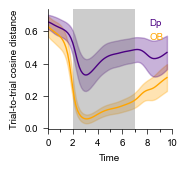

In [95]:
fig, ax = plt.subplots(figsize=(1.6, 1.55))
from catrace.similarity import plot_same_odor_diff_trial

# start_time = 2.0
start_time = 2.3
ob_start = np.round(start_time * 7.5 - 2.5) # The sliding window is 5 frames, so we subtract 2.5 frames, such that the time point is the center of the window
dp_start = np.round(start_time * 7.5 - 2.5)
total_time = np.round(10.0 * 7.5 - 2.5)
ob_simdf_sel = convert_frame_to_time(select_time_window_simdf(ob_simdf, [ob_start, ob_start+total_time]), frame_rate=7.5, time_names=['start_time', 'end_time'])
dp_simdf_sel = convert_frame_to_time(select_time_window_simdf(dp_simdf, [dp_start, dp_start+total_time]), frame_rate=7.5, time_names=['start_time', 'end_time'])

trial_to_trial_ob = plot_same_odor_diff_trial(ob_simdf_sel, num_trials=3, ax=ax, color='orange', label='OB', return_data=True) #orange #F5A623
trial_to_trial_dp = plot_same_odor_diff_trial(dp_simdf_sel, num_trials=3, ax=ax, color='indigo', label='Dp', return_data=True) #indigo #3954A7

if metric == 'pattern_correlation':
    ylabel = 'Trial-to-trial pattern corr.'
elif metric == 'cosine':
    ylabel = 'Trial-to-trial cosine distance'
else:
    ylabel = metric
ax.set_ylabel(ylabel, fontsize=7)
ax.set_xlabel('Time', fontsize=7)
ax.tick_params(labelsize=7)
ax.legend(title='Region', fontsize=7, title_fontsize=7)
ax.set_title(None)

ax.set_xlim(0, 10)
# Set xticks with interval of 2 using multiplelocator
from matplotlib.ticker import MultipleLocator
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.xaxis.set_minor_locator(MultipleLocator(1))

import matplotlib.lines as mlines
import matplotlib.pyplot as plt

ax = plt.gca()   # seaborn already plotted on this

# Get existing legend entries from seaborn
handles, labels = ax.get_legend_handles_labels()

# Pick your desired order (an ordered list of label names)
desired_order = ["Dp", "OB"]

# Reorder handles and labels
ordered_handles = []
ordered_labels = []

for name in desired_order:
    idx = labels.index(name)        # find the index for that label
    ordered_handles.append(handles[idx])
    ordered_labels.append(labels[idx])

# Create invisible handles (no line markers in legend)
dummy_handles = [mlines.Line2D([], [], linestyle='none') for _ in ordered_handles]

# Build the legend
legend = ax.legend(
    dummy_handles,
    ordered_labels,
    title=None,
    frameon=False,
    fontsize=7,
    loc='upper right'
)

# Color the text to match the actual line colors
for text_obj, real_handle in zip(legend.get_texts(), ordered_handles):
    try:
        color = real_handle.get_color()
    except AttributeError:
        color = real_handle.get_facecolor()
    text_obj.set_color(color)




from catrace.plot_trace import add_time_range_rectangle
time_range = (2, 7)
add_time_range_rectangle(ax, time_range, color='gray', alpha=0.4, text=None, fontsize=6, text_offset=0.02)

sns.despine()

paper_fig_dir = '../../figures_for_paper/juvenile/trial_to_trial_variability/'
fig_name = f'trial_to_trial_{metric}'
# Save figure
os.makedirs(paper_fig_dir, exist_ok=True)
save_path = pjoin(paper_fig_dir, f'{fig_name}.pdf')
fig.savefig(save_path, bbox_inches='tight')


In [96]:
# Reorder the column levels to fish_id, condition, odor, trial
trial_to_trial_ob_to_save = trial_to_trial_ob.dropna(axis=1).reorder_levels(['fish_id', 'condition', 'odor', 'trial'], axis=1)
# Drop level trial
trial_to_trial_ob_to_save.columns = trial_to_trial_ob_to_save.columns.droplevel('trial')
trial_to_trial_dp_to_save = trial_to_trial_dp.dropna(axis=1).reorder_levels(['fish_id', 'condition', 'odor', 'trial'], axis=1)
# Drop level trial
trial_to_trial_dp_to_save.columns = trial_to_trial_dp_to_save.columns.droplevel('trial')

trial_to_trial_ob_to_save


,fish_id,2021-02-05-DpOBEM-JH9_OB,2021-03-18-DpOBEM-JH10_OB,2021-03-19-DpOBEM-JH10_OB,2021-04-02-DpOBEM-JH11_OB,2021-04-03-DpOBEM-JH11_OB,2021-05-01-DpOBEM-JH13_OB,2021-05-22-DpOBEM-JH14_OB,2021-07-15-DpOBEM-N2_OB,2021-07-16-DpOBEM-N3_OB,2021-07-30-DpOBEM-JH17_OB,...,2021-11-10-DpOBEM-JH23_OB,2021-11-11-DpOBEM-JH23_OB,2021-11-14-DpOBEM-JH23_OB,2021-11-24-DpOBEM-JH24_OB,2021-11-26-DpOBEM-JH24_OB,2021-11-27-DpOBEM-JH24_OB,2021-12-10-DpOBEM-N4_OB,2021-12-31-DpOBEM-N7_OB,2022-02-13-DpOBEM-N10_OB,2022-02-20-DpOBEM-N11_OB
,condition,phe-arg,phe-arg,phe-arg,phe-arg,phe-arg,phe-arg,phe-arg,naive,naive,arg-phe,...,phe-trp,phe-trp,phe-trp,phe-trp,phe-trp,phe-trp,naive,naive,naive,naive
,odor,Phe,Phe,Phe,Phe,Phe,Phe,Phe,Phe,Phe,Phe,...,GCA,GCA,GCA,GCA,GCA,GCA,GCA,GCA,GCA,GCA
start_time,end_time,,,,,,,,,,,,,,,,,,,,,
0.000000,0.666667,0.659357,0.659398,0.626041,0.623629,0.515623,0.552963,0.589060,0.645295,0.640436,0.632143,...,0.669240,0.738260,0.640486,0.684926,0.730511,0.536285,0.641468,0.703165,0.634334,0.622683
0.133333,0.800000,0.650945,0.652320,0.609892,0.592260,0.509265,0.550077,0.603644,0.630860,0.616134,0.666198,...,0.660103,0.740491,0.631629,0.673294,0.725281,0.549143,0.640317,0.673302,0.618342,0.625895
0.266667,0.933333,0.643279,0.648898,0.595962,0.550656,0.506376,0.550030,0.618740,0.610261,0.594314,0.692568,...,0.649807,0.755334,0.614579,0.664572,0.719558,0.556457,0.639735,0.652497,0.603951,0.626826
0.400000,1.066667,0.634589,0.648787,0.585856,0.508640,0.506437,0.548776,0.624187,0.588327,0.577750,0.702118,...,0.637905,0.775793,0.592340,0.656665,0.712459,0.572954,0.637703,0.640866,0.599099,0.626199
0.533333,1.200000,0.624513,0.653705,0.575808,0.467332,0.504679,0.546188,0.617404,0.577102,0.573947,0.692425,...,0.630623,0.793876,0.570309,0.648009,0.704400,0.598745,0.629657,0.634682,0.603833,0.619248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9.066667,9.733333,0.396895,0.354410,0.320895,0.289609,0.261418,0.310690,0.419726,0.171982,0.233311,0.277443,...,0.363671,0.156073,0.402553,0.353041,0.331367,0.394700,0.284757,0.438396,0.225480,0.381136


In [97]:


# Concatenate trial_to_trial_ob_to_save and trial_to_trial_dp_to_save along a new level 'region' along the columns
combined_trial_to_trial_to_save = pd.concat([trial_to_trial_ob_to_save, trial_to_trial_dp_to_save], keys=['OB', 'Dp'], names=['region', 'fish_id', 'condition', 'odor'], axis=1)
combined_trial_to_trial_to_save


region                                     OB                            \
fish_id              2021-02-05-DpOBEM-JH9_OB 2021-03-18-DpOBEM-JH10_OB   
condition                             phe-arg                   phe-arg   
odor                                      Phe                       Phe   
start_time end_time                                                       
0.000000   0.666667                  0.659357                  0.659398   
0.133333   0.800000                  0.650945                  0.652320   
0.266667   0.933333                  0.643279                  0.648898   
0.400000   1.066667                  0.634589                  0.648787   
0.533333   1.200000                  0.624513                  0.653705   
...                                       ...                       ...   
9.066667   9.733333                  0.396895                  0.354410   
9.200000   9.866667                  0.411278                  0.362402   
9.333333   10.000000                 0.426452                  0.365970   
9.466667   10.133333                 0.441072                  0.360046   
9.600000   10.266667                 0.454912                  0.345909   

region                                                                    \
fish_id              2021-03-19-DpOBEM-JH10_OB 2021-04-02-DpOBEM-JH11_OB   
condition                              phe-arg                   phe-arg   
odor                                       Phe                       Phe   
start_time end_time                                                        
0.000000   0.666667                   0.626041                  0.623629   
0.133333   0.800000                   0.609892                  0.592260   
0.266667   0.933333                   0.595962                  0.550656   
0.400000   1.066667                   0.585856                  0.508640   
0.533333   1.200000                   0.575808                  0.467332   
...                                        ...                       ...   
9.066667   9.733333                   0.320895                  0.289609   
9.200000   9.866667                   0.334248                  0.299265   
9.333333   10.000000                  0.345597                  0.302964   
9.466667   10.133333                  0.355492                  0.305366   
9.600000   10.266667                  0.363604                  0.306444   

region                                                                    \
fish_id              2021-04-03-DpOBEM-JH11_OB 2021-05-01-DpOBEM-JH13_OB   
condition                              phe-arg                   phe-arg   
odor                                       Phe                       Phe   
start_time end_time                                                        
0.000000   0.666667                   0.515623                  0.552963   
0.133333   0.800000                   0.509265                  0.550077   
0.266667   0.933333                   0.506376                  0.550030   
0.400000   1.066667                   0.506437                  0.548776   
0.533333   1.200000                   0.504679                  0.546188   
...                                        ...                       ...   
9.066667   9.733333                   0.261418                  0.310690   
9.200000   9.866667                   0.246209                  0.311145   
9.333333   10.000000                  0.239981                  0.305064   
9.466667   10.133333                  0.245000                  0.299661   
9.600000   10.266667                  0.255120                  0.300794   

region                                                                  \
fish_id              2021-05-22-DpOBEM-JH14_OB 2021-07-15-DpOBEM-N2_OB   
condition                              phe-arg                   naive   
odor                                       Phe                     Phe   
start_time end_time                                                  

In [98]:

# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'extended_figure03')
os.makedirs(save_dir, exist_ok=True)
combined_trial_to_trial_to_save.to_csv(os.path.join(save_dir, f'extended_figure03c_trial_to_trial_{metric}_timecourse.csv'))